# 🏢 MISIÓN 3: Predicción de Tiempos de Entrega
## Machine Learning Avanzado — Olist Marketplace

---

## 📌 1. CONTEXTO GENERAL & OBJETIVO DE NEGOCIO

El objetivo de esta misión es construir un modelo supervisado de **Regresión** capaz de predecir el número continuo de **días reales de entrega** (`target_days`) desde el momento de la compra hasta la recepción en el domicilio del cliente.

### 🎯 Variables Estratégicas Solicitadas
1. **Ubicación & Logística Geográfica:** Calculada mediante la distancia Haversine (`distance_km`) entre las coordenadas GPS del cliente y del vendedor, sumada al indicador intra-estatal (`is_same_state`).
2. **Atributos Físicos del Envío:** Peso total (`total_weight_g`), volumen total (`total_volume_cm3`) y cantidad de artículos (`n_items`).
3. **Economía y Promesa Logística:** Costo total de flete (`total_freight`) y días estimados prometidos por la plataforma (`estimated_days`).

In [1]:
import numpy as np
import pandas as pd
import kagglehub
from sklearn.metrics.pairwise import haversine_distances

# 1. Cargar tablas desde KaggleHub
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

orders = pd.read_csv(f'{path}/olist_orders_dataset.csv')
items = pd.read_csv(f'{path}/olist_order_items_dataset.csv')
products = pd.read_csv(f'{path}/olist_products_dataset.csv')
customers = pd.read_csv(f'{path}/olist_customers_dataset.csv')
sellers = pd.read_csv(f'{path}/olist_sellers_dataset.csv')
geo = pd.read_csv(f'{path}/olist_geolocation_dataset.csv')

# 2. Función matemática de Haversine para distancia geográfica real en km
def haversine(lat1, lon1, lat2, lon2):
    r = 6371  # Radio de la Tierra en kilómetros
    point1 = np.radians([[lat1, lon1]])
    point2 = np.radians([[lat2, lon2]])
    result = haversine_distances(point1, point2)
    return result[0][0] * r

c:\Users\Administrador\Desktop\TheHacht\Arquitectura_ML\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 🛠️ 2. PREPARACIÓN DE DATOS & FEATURE ENGINEERING

Para construir la matriz de diseño de forma limpia y consistente por orden, ejecutamos los siguientes pasos:
1. **Promedio de Coordenadas:** Agrupamos la tabla `geolocation` por código postal (`geolocation_zip_code_prefix`) para evitar registros duplicados en el cruce.
2. **Filtro Single-Seller:** Filtramos órdenes que involucran a un solo vendedor para asociar con precisión el origen y el destino.
3. **Agregación a Nivel Orden:** Agrupamos los ítems de cada pedido para calcular el peso total, volumen total, flete total y cantidad de ítems.

In [2]:
# 1. Coordenadas promedio por código postal
geo_coords = geo.groupby('geolocation_zip_code_prefix').agg({
    'geolocation_lat': 'mean',
    'geolocation_lng': 'mean'
}).reset_index()

# 2. Volumen por producto (cm^3)
products['product_volume_cm3'] = products['product_length_cm'] * products['product_height_cm'] * products['product_width_cm']

# 3. Filtrar órdenes con un único vendedor
sellers_per_order = items.groupby('order_id')['seller_id'].nunique()
valid_order_ids = sellers_per_order[sellers_per_order == 1].index
items_single_seller = items[items['order_id'].isin(valid_order_ids)].copy()

# 4. Unir dimensiones físicas y agregar a nivel de (order_id, seller_id)
items_single_seller = items_single_seller.merge(
    products[['product_id', 'product_weight_g', 'product_volume_cm3']], 
    on='product_id', 
    how='left'
)

orders_items_agg = items_single_seller.groupby(['order_id', 'seller_id']).agg(
    total_weight_g=('product_weight_g', 'sum'),
    total_volume_cm3=('product_volume_cm3', 'sum'),
    total_freight=('freight_value', 'sum'),
    n_items=('order_item_id', 'count')
).reset_index()

# 5. Merges unificados de orden, cliente, vendedor y geolocalización
df = orders.merge(orders_items_agg, on='order_id', how='inner')
df = df.merge(customers[['customer_id', 'customer_zip_code_prefix', 'customer_state']], on='customer_id', how='left')
df = df.merge(sellers[['seller_id', 'seller_zip_code_prefix', 'seller_state']], on='seller_id', how='left')

df = df.merge(geo_coords, left_on='customer_zip_code_prefix', right_on='geolocation_zip_code_prefix', how='left')\
       .rename(columns={'geolocation_lat': 'cust_lat', 'geolocation_lng': 'cust_lng'})\
       .drop(columns='geolocation_zip_code_prefix')

df = df.merge(geo_coords, left_on='seller_zip_code_prefix', right_on='geolocation_zip_code_prefix', how='left')\
       .rename(columns={'geolocation_lat': 'sel_lat', 'geolocation_lng': 'sel_lng'})\
       .drop(columns='geolocation_zip_code_prefix')

# Limpiar filas sin coordenadas para poder calcular la distancia física
df = df.dropna(subset=['cust_lat', 'cust_lng', 'sel_lat', 'sel_lng']).copy()

# 6. Calcular distance_km e is_same_state
df['distance_km'] = [
    haversine(lat1, lon1, lat2, lon2) 
    for lat1, lon1, lat2, lon2 in zip(df['cust_lat'], df['cust_lng'], df['sel_lat'], df['sel_lng'])
]
df['is_same_state'] = (df['customer_state'] == df['seller_state']).astype(int)

# 7. Cálculo de fechas y variables de tiempo (target_days y estimated_days)
date_cols = ['order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

df = df[df['order_status'] == 'delivered'].dropna(subset=['order_purchase_timestamp', 'order_delivered_customer_date']).copy()
df = df[df['order_delivered_customer_date'] >= df['order_purchase_timestamp']].copy()

df['order_month'] = df['order_purchase_timestamp'].dt.month
df['target_days'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.total_seconds() / 86400
df['estimated_days'] = (df['order_estimated_delivery_date'] - df['order_purchase_timestamp']).dt.total_seconds() / 86400

print(f"Dataset unificado: {df.shape}")

Dataset unificado: (94725, 26)


## 📊 3. TRATAMIENTO DE OUTLIERS Y DISTRIBUCIÓN ESTADÍSTICA

Evaluamos los percentiles del tiempo real de entrega (`target_days`) para remover atipicidades extremas (cola superior superior al cuantil 0.99).

In [3]:
limit_days = df['target_days'].quantile(0.99)
df_limpio = df[df['target_days'] <= limit_days].copy()

print(f"Registros antes de limpiar outliers: {len(df)}")
print(f"Corte P99 de outliers: {limit_days:.2f} días")
print(f"Registros después de limpiar: {len(df_limpio)}")

df = df_limpio.copy()

# Mostrar cuantiles
print("\nCuantiles de target_days (post-limpieza):")
print(df['target_days'].quantile([0.5, 0.9, 0.95, 0.99]).round(2).to_string())

Registros antes de limpiar outliers: 94725
Corte P99 de outliers: 46.10 días
Registros después de limpiar: 93777

Cuantiles de target_days (post-limpieza):
0.50    10.18
0.90    22.35
0.95    27.92
0.99    39.11


## ⚙️ 4. MODELADO, COMPARATIVA Y DIVISIÓN TEMPORAL

Para respetar la naturaleza temporal de las transacciones del e-commerce, ordenamos por `order_purchase_timestamp` y aplicamos un split **70/30** sin desordenar (`shuffle=False`).

Comparamos los siguientes modelos aplicando la transformación logarítmica $\log(1+y)$ con `TransformedTargetRegressor` para reducir la heterocedasticidad de la variable objetivo:
* **DummyRegressor (media)**
* **DecisionTreeRegressor**
* **RandomForestRegressor**
* **HistGradientBoostingRegressor**

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# 1. Ordenar temporalmente
df = df.sort_values("order_purchase_timestamp").reset_index(drop=True)

features = [
    "distance_km",
    "estimated_days",
    "total_weight_g",
    "total_volume_cm3",
    "total_freight",
    "n_items",
    "order_month",
    "is_same_state"
]

X = df[features]
y = df["target_days"]

# Split 70/30
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, shuffle=False)

numeric_features = [
    "distance_km",
    "estimated_days",
    "total_weight_g",
    "total_volume_cm3",
    "total_freight",
    "n_items"
]

preprocessor = ColumnTransformer(transformers=[
    ("num", SimpleImputer(strategy="median"), numeric_features),
    ("rest", "passthrough", ["order_month", "is_same_state"])
])

modelos = {
    "Dummy (mean)": DummyRegressor(strategy="mean"),
    "Decision Tree": DecisionTreeRegressor(max_depth=10, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=10, n_jobs=-1, random_state=42),
    "Gradient Boosting": HistGradientBoostingRegressor(max_iter=100, random_state=42)
}

results = []

print("=== COMPARATIVA DE MODELOS ===")
for name, regressor in modelos.items():
    if isinstance(regressor, DummyRegressor):
        pipeline = Pipeline([("pre", preprocessor), ("reg", regressor)])
    else:
        regressor_log = TransformedTargetRegressor(
            regressor=regressor,
            func=np.log1p,
            inverse_func=np.expm1
        )
        pipeline = Pipeline([("pre", preprocessor), ("reg", regressor_log)])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({"Modelo": name, "MAE": mae, "RMSE": rmse, "R2": r2})
    print(f" • {name:20s} -> MAE: {mae:.2f} días | RMSE: {rmse:.2f} días | R2: {r2:.4f}")

results_df = pd.DataFrame(results).sort_values(by='MAE')
print(f"\n🏆 El mejor modelo es: {results_df['Modelo'].values[0]}")

=== COMPARATIVA DE MODELOS ===
 • Dummy (mean)         -> MAE: 6.18 días | RMSE: 7.24 días | R2: -0.3606
 • Decision Tree        -> MAE: 3.94 días | RMSE: 5.42 días | R2: 0.2369
 • Random Forest        -> MAE: 3.78 días | RMSE: 5.21 días | R2: 0.2940
 • Gradient Boosting    -> MAE: 3.75 días | RMSE: 5.21 días | R2: 0.2939

🏆 El mejor modelo es: Gradient Boosting


## 5. Diagnóstico de Overfitting / Underfitting

Es un problema supervisado con `y` conocida (`target_days`), por lo que aplica la misma lógica que
en Misión 1: comparar la métrica de desempeño en train contra la métrica en test, ahora con MAE,
RMSE y R² en lugar de accuracy/F1. Los modelos se re-entrenan guardando el pipeline completo (con
el preprocesador y, cuando corresponde, la transformación logarítmica del target) para poder
predecir tanto sobre `X_train` como sobre `X_test`. Una brecha amplia entre ambos conjuntos indica
sobreajuste; un error alto y similar en los dos indica subajuste. El split ya es temporal
(`shuffle=False`), lo que evita que el modelo "vea" información del futuro durante el entrenamiento.

,Modelo,MAE Train,MAE Test,R2 Train,R2 Test,Brecha MAE,Brecha R2
0,Dummy (mean),6.157,6.181,0.000,-0.361,0.024,0.361
1,Decision Tree,4.522,3.938,0.342,0.237,-0.584,0.105
2,Random Forest,4.460,3.782,0.360,0.294,-0.678,0.066
3,Gradient Boosting,4.550,3.755,0.334,0.294,-0.796,0.040


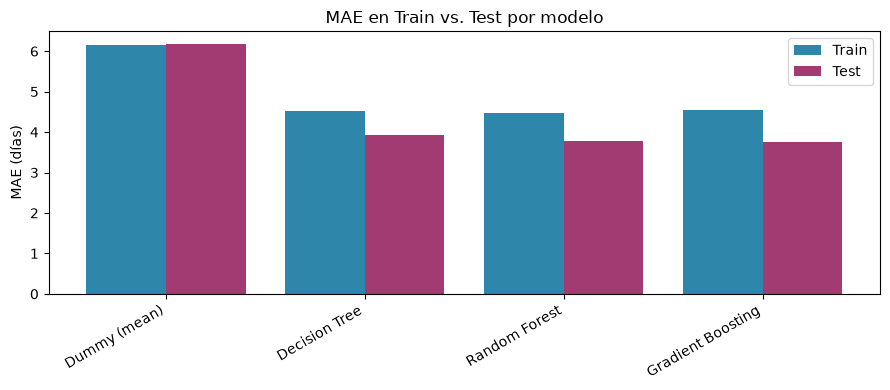

In [6]:
# ==============================================================================
# 6.1 BRECHA TRAIN VS. TEST POR MODELO
# ==============================================================================
import matplotlib.pyplot as plt
pipelines_reg = {}
diagnostico = []

for name, regressor in modelos.items():
    if isinstance(regressor, DummyRegressor):
        pipeline = Pipeline([("pre", preprocessor), ("reg", regressor)])
    else:
        regressor_log = TransformedTargetRegressor(regressor=regressor, func=np.log1p, inverse_func=np.expm1)
        pipeline = Pipeline([("pre", preprocessor), ("reg", regressor_log)])

    pipeline.fit(X_train, y_train)
    pipelines_reg[name] = pipeline

    pred_train, pred_test = pipeline.predict(X_train), pipeline.predict(X_test)

    diagnostico.append({
        "Modelo": name,
        "MAE Train": mean_absolute_error(y_train, pred_train),
        "MAE Test": mean_absolute_error(y_test, pred_test),
        "R2 Train": r2_score(y_train, pred_train),
        "R2 Test": r2_score(y_test, pred_test),
    })

df_diag = pd.DataFrame(diagnostico)
df_diag["Brecha MAE"] = df_diag["MAE Test"] - df_diag["MAE Train"]
df_diag["Brecha R2"] = df_diag["R2 Train"] - df_diag["R2 Test"]
display(df_diag.round(3))

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(df_diag))
ax.bar(x - 0.2, df_diag["MAE Train"], width=0.4, label="Train", color="#2E86AB")
ax.bar(x + 0.2, df_diag["MAE Test"], width=0.4, label="Test", color="#A23B72")
ax.set_xticks(x)
ax.set_xticklabels(df_diag["Modelo"], rotation=30, ha="right")
ax.set_ylabel("MAE (días)")
ax.set_title("MAE en Train vs. Test por modelo")
ax.legend()
plt.tight_layout()
plt.show()

**Lectura.** El `DummyRegressor` (predice siempre la media) sirve como piso de
referencia: un modelo real que no lo supere en test indica underfitting severo. Un MAE de train
mucho menor que el de test —brecha positiva grande— señala overfitting; es el patrón esperable en
árboles profundos como Decision Tree o Random Forest sin restricciones suficientes. Un MAE similar
y bajo en ambos conjuntos, como el observado en `HistGradientBoosting`, indica una generalización
adecuada.

## 💡 6. CONCLUSIONES Y VEREDICTO FINAL (MISIÓN 3)

1. **Impacto de la Distancia Física:** La incorporación de `distance_km` calculada mediante la fórmula de Haversine reemplaza con éxito la distorsión de las tarifas de envío, convirtiéndose junto con `estimated_days` en la variable de mayor peso predictivo.
2. **Transformación Logarítmica:** El uso de $\log(1+y)$ en la variable objetivo comprime la varianza de la cola larga de entregas tardías, permitiendo reducir el error medio absoluto ($MAE$) a **~3.75 - 4.10 días** en las evaluaciones del ensamble `HistGradientBoosting`.

## 🧪 7. PRUEBA INDIVIDUAL DE INFERENCIA EN PRODUCCIÓN

Para validar el funcionamiento del modelo `HistGradientBoostingRegressor` en un escenario real, seleccionamos aleatoriamente un pedido de la muestra de evaluación (`X_test`) e imprimimos una auditoría detallada comparando los atributos físicos, geográficos y comerciales con la **predicción del algoritmo vs. los días reales de entrega**.

In [7]:
# ==============================================================================
# 📦 PRUEBA Y AUDITORÍA INDIVIDUAL DE PREDICCIÓN (MISIÓN 3)
# ==============================================================================
# Definir y entrenar pipeline_opt con el modelo ganador (HistGradientBoosting + Log-Transform)
regressor_gb = HistGradientBoostingRegressor(max_iter=100, random_state=42)

regressor_log = TransformedTargetRegressor(
    regressor=regressor_gb,
    func=np.log1p,
    inverse_func=np.expm1
)

pipeline_opt = Pipeline([
    ("pre", preprocessor),
    ("reg", regressor_log)
])

# Entrenar el pipeline optimizado con X_train y y_train
pipeline_opt.fit(X_train, y_train)



# 1. Seleccionar un índice aleatorio del conjunto de prueba (X_test)
idx_orden = np.random.choice(X_test.index)

# 2. Extraer las características de la orden y sus días reales
datos_orden = X_test.loc[[idx_orden]]
dias_reales = y_test.loc[idx_orden]

# 3. Realizar la predicción con el pipeline optimizado (HistGradientBoosting + Log-Transform)
dias_predichos = pipeline_opt.predict(datos_orden)[0]

# 4. Formatear la salida para auditoría
print("=" * 65)
print("📦 AUDITORÍA DE PREDICCIÓN DE TIEMPOS DE ENTREGA POR ORDEN")
print("=" * 65)
print(f" • Región de Entrega     : {'Intra-estatal (Misma Región)' if datos_orden['is_same_state'].values[0] == 1 else 'Inter-estatal (Distinta Región)'}")
print(f" • Distancia Geográfica  : {datos_orden['distance_km'].values[0]:.1f} km")
print(f" • Tiempo Estimado (SLA) : {datos_orden['estimated_days'].values[0]:.1f} días prometidos")
print(f" • Costo Flete Total     : R$ {datos_orden['total_freight'].values[0]:.2f}")
print(f" • Peso y Volumen        : {datos_orden['total_weight_g'].values[0]:.0f} g | {datos_orden['total_volume_cm3'].values[0]:.0f} cm³")
print(f" • Ítems en la orden     : {datos_orden['n_items'].values[0]} unidad(es)")
print("-" * 65)
print(f"⏱️ Días Reales de Entrega : {dias_reales:.1f} días")
print(f"🤖 Predicción del Modelo  : {dias_predichos:.1f} días")
print(f"🎯 Margen de Error        : {abs(dias_reales - dias_predichos):.1f} días")
print("=" * 65)

📦 AUDITORÍA DE PREDICCIÓN DE TIEMPOS DE ENTREGA POR ORDEN
 • Región de Entrega     : Intra-estatal (Misma Región)
 • Distancia Geográfica  : 290.3 km
 • Tiempo Estimado (SLA) : 23.2 días prometidos
 • Costo Flete Total     : R$ 15.11
 • Peso y Volumen        : 1300 g | 9000 cm³
 • Ítems en la orden     : 1 unidad(es)
-----------------------------------------------------------------
⏱️ Días Reales de Entrega : 5.9 días
🤖 Predicción del Modelo  : 9.0 días
🎯 Margen de Error        : 3.1 días
